In [1]:
import uproot
import awkward as ak
import vector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from numba_stats import bernstein
from iminuit import cost, Minuit
import os

# set plt style
plt.style.use('hep.mplstyle')

# load our modules
import sys
sys.path.append('..')
from src.data_loader import (
    download_data_files,
    load_data_from_root_files,
    plot_mass_histogram
)
from src.selection import (
    apply_selection,
    select_diphoton_events,
    apply_photon_quality_cuts
)
from src.models import (
    cbg_pdf,
    cbg_cdf,
    bernstein_pdf,
    bernstein_cdf
)
DATA_DIR = "../datasets"

## 1. Data Preprocess

1.1 Load Data

1.2 Data Selection - 1

1.3 Data Selection - 2

Relevant selection functions are implemented in `src/selection.py` for readability.

### 1.1 Load Data

In [2]:
path = "https://atlas-opendata.web.cern.ch/atlas-opendata/13TeV/GamGam/Data/"

file_list = [
    "data15_periodD.root",
    "data15_periodE.root",
    "data15_periodF.root",
    "data15_periodG.root",
    "data15_periodH.root",
    "data15_periodJ.root",
    "data16_PeriodI.root",
    "data16_periodA.root",
    "data16_periodB.root",
    "data16_periodC.root",
    "data16_periodD.root",
    "data16_periodE.root",
    "data16_periodF.root",
    "data16_periodG.root",
    "data16_periodK.root",
    "data16_periodL.root"
]
# Download data files if not exist locally
download_data_files(path, file_list, DATA_DIR)

In [3]:
# Extract rel
df = ak.to_dataframe(uproot.concatenate(f"{DATA_DIR}/data*.root",
                                        filter_name=['photon_n', 
                                                     'photon_pt', 
                                                     'photon_eta', 
                                                     'photon_phi', 
                                                     'photon_e', 
                                                     'photon_isTightID', # tight photon ID
                                                     'photon_isTightIso'], # tight isolation
                                        library='ak'))
df.head()

photon_n  photon_pt  photon_eta  photon_phi   photon_e  \
entry subentry                                                           
0     0                4  84.029915   -0.379076    2.926059  90.140045   
      1                4  27.705812    0.822981   -0.087787  37.630032   
      2                4   9.295130    0.822584   -0.148857  12.621251   
      3                4   2.561815    0.495293    0.397490   2.882517   
1     0                3  26.147392    0.646658   -0.195641  31.807554   

                photon_isTightID  photon_isTightIso  
entry subentry                                       
0     0                     True               True  
      1                    False              False  
      2                    False              False  
      3                    False              False  
1     0                    False              False

### 1.2 Data Selection - 1

1. `photon_n == 2` 
2. `photon_pt`, `photon_eta`, `photon_phi`, `photon_e`

In [4]:
df = select_diphoton_events(df, mass_range=(100, 160))
df.head()

Mass range selection efficiency: 0.1675


photon_n   photon_pt  photon_eta  photon_phi    photon_e  \
entry subentry                                                             
5     0                2  125.201828   -0.738252    2.906022  160.898300   
      1                2   23.794893   -1.915885   -0.460797   82.570168   
56    0                2   83.005539    1.693584   -0.613051  233.361725   
      1                2   73.862511    1.159767    0.796867  129.360947   
74    0                2  161.343155   -0.773416    2.218638  212.052612   

                photon_isTightID  photon_isTightIso     higgs_m  
entry subentry                                                   
5     0                    False              False  128.054062  
      1                    False              False  128.054062  
56    0                     True              False  109.939896  
      1                     True               True  109.939896  
74    0                    False              False  158.361679

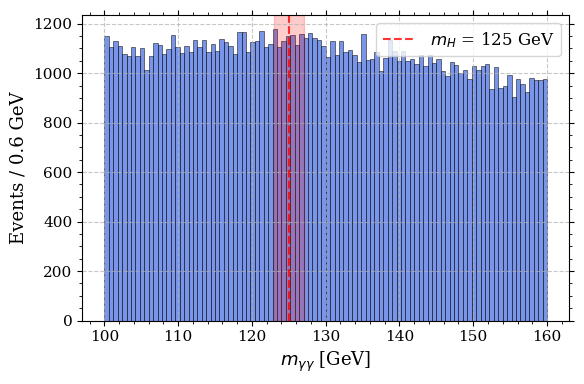

In [5]:
plot_mass_histogram(df)

### 1.3 Data Selection - 2

1. `photon_pt`
2. `photon_isTightID`
    - high-quality photon
3. `photon_isTightIso`
    - equivalent to (`photon_ptcone30`/`photon_pt` < 0.065) && (`photon_etcone20`/`photon_pt` < 0.065) -> True
4. `df['photon_ptom'] = df['photon_pt'] / df['higgs_m']`
    - photon_ptom[:, 0] > 0.35 && photon_ptom[:, 1] > 0.35
    

In [6]:
# 1. pT cuts: leading > 50 GeV, subleading > 35 GeV
# 2. Tight ID and isolation cuts
# 3. Energy ratio cuts: pT/m_H > 0.35 for both photons
df = apply_photon_quality_cuts(df)
df.head()

Photon pT efficiency: 0.2918
Photon ID efficiency: 0.1991
Photon isolation efficiency: 0.4193
Energy ratio efficiency: 0.6843


photon_n   photon_pt  photon_eta  photon_phi    photon_e  \
entry subentry                                                             
4605  0                2  100.601181   -1.559228   -2.543222  249.764908   
      1                2   51.526695   -1.189263    0.330684   92.467361   
6797  0                2   62.696762    1.979826   -2.066047  231.337723   
      1                2   56.856785    2.218926    0.770329  264.559662   
14575 0                2   64.280777    0.456663    1.302109   71.100655   

                photon_isTightID  photon_isTightIso     higgs_m photon_passPT  \
entry subentry                                                                  
4605  0                     True               True  145.199829          True   
      1                     True               True  145.199829          True   
6797  0                     True               True  118.887421          True   
      1                     True               True  118.887421          True   
14575 0                     True               True  102.031090          True   

               photon_passID passIso  photon_ptom passEnergyRatio  
entry subentry                                                     
4605  0                 True    True     0.692846            True  
      1                 True    True     0.354867            True  
6797  0                 True    True     0.527362            True  
      1                 True    True     0.478241            True  
14575 0                 True    True     0.630012            True

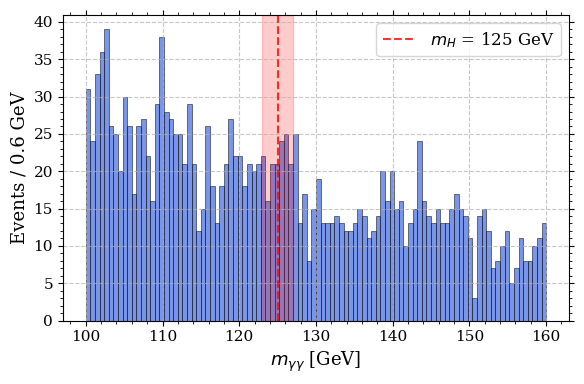

In [7]:
plot_mass_histogram(df)

## Fit

### MC data fit

In [8]:
fpath = "https://atlas-opendata.web.cern.ch/atlas-opendata/samples/2020/GamGam/"

flist = ["mc_343981.ggH125_gamgam.GamGam.root",
         "mc_345041.VBFH125_gamgam.GamGam.root",
         "mc_345318.WpH125J_Wincl_gamgam.GamGam.root",
         "mc_345319.ZH125J_Zincl_gamgam.GamGam.root",
         "mc_341081.ttH125_gamgam.GamGam.root"
        ]

# Download MC files if not exist locally
download_data_files(fpath, flist, DATA_DIR)

In [9]:
mc = uproot.concatenate("../datasets/mc_*.GamGam.root:mini",
                                          filter_name=['XSection', 
                                                       'mcWeight', 
                                                       'SumWeights',
                                                       'photon_n', 
                                                       'photon_pt', 
                                                       'photon_eta', 
                                                       'photon_phi', 
                                                       'photon_E', 
                                                       'photon_isTightID',
                                                       'photon_ptcone30',
                                                       'photon_etcone20'],
                                          library='ak')

# create photon_isTightIso column
passIso = (
    (mc['photon_ptcone30'][:, 0] / mc['photon_pt'][:, 0] < 0.065) &
    (mc['photon_ptcone30'][:, 1] / mc['photon_pt'][:, 1] < 0.065) &
    (abs(mc['photon_etcone20'][:, 0]) / mc['photon_pt'][:, 0] < 0.065) &
    (abs(mc['photon_etcone20'][:, 1]) / mc['photon_pt'][:, 1] < 0.065)
)
mc = ak.with_field(mc, passIso, 'photon_isTightIso')

mcdf = ak.to_dataframe(mc)

# Rename photon_E to photon_e
mcdf = mcdf.rename(columns={'photon_E': 'photon_e'})

# Convert MeV to GeV
mcdf['photon_pt'] /= 1000
mcdf['photon_e'] /= 1000
mcdf['photon_ptcone30'] /= 1000
mcdf['photon_etcone20'] /= 1000

mcdf.head()

mcWeight  photon_n   photon_pt  photon_eta  photon_phi  \
entry subentry                                                           
0     0             -1.0         2   65.113243    0.457411    0.035015   
      1             -1.0         2   42.407703   -0.955203   -2.357092   
1     0             -1.0         2   95.446815   -1.096723   -1.753266   
      1             -1.0         2   65.492104    0.242537   -2.509430   
2     0             -1.0         2  110.997566    0.066561    0.874751   

                  photon_e  photon_isTightID  photon_ptcone30  \
entry subentry                                                  
0     0          72.044487              True         0.000000   
      1          63.270855              True         0.000000   
1     0         158.837875              True         0.000000   
      1          67.427818              True         0.000000   
2     0         111.243538              True         6.868898   

                photon_etcone20  XSection  SumWeights  photon_isTightIso  
entry subentry                                                            
0     0                0.021420  0.000003    485440.0               True  
      1               -0.057134  0.000003    485440.0               True  
1     0               -1.700163  0.000003    485440.0               True  
      1                0.234058  0.000003    485440.0               True  
2     0                5.708004  0.000003    485440.0              False

In [10]:
mcdf = select_diphoton_events(mcdf, mass_range=(100, 160))
mcdf = apply_photon_quality_cuts(mcdf)
mcdf.head()

Mass range selection efficiency: 0.9946
Photon pT efficiency: 0.8179
Photon ID efficiency: 0.8012
Photon isolation efficiency: 0.8647
Energy ratio efficiency: 0.8008


mcWeight  photon_n   photon_pt  photon_eta  photon_phi  \
entry subentry                                                           
1     0             -1.0         2   95.446815   -1.096723   -1.753266   
      1             -1.0         2   65.492104    0.242537   -2.509430   
4     0              1.0         2   71.947571   -1.099955   -0.109149   
      1              1.0         2   61.528793   -1.535534   -2.482499   
10    0              1.0         2  226.258759    0.092213    1.914124   

                  photon_e  photon_isTightID  photon_ptcone30  \
entry subentry                                                  
1     0         158.837875              True         0.000000   
      1          67.427818              True         0.000000   
4     0         120.041489              True         0.000000   
      1         149.488632              True         1.839824   
10    0         227.221405              True         0.000000   

                photon_etcone20  XSection  SumWeights  photon_isTightIso  \
entry subentry                                                             
1     0               -1.700163  0.000003    485440.0               True   
      1                0.234058  0.000003    485440.0               True   
4     0               -2.719705  0.000003    485440.0               True   
      1               -0.554828  0.000003    485440.0               True   
10    0               -3.038387  0.000003    485440.0               True   

                   higgs_m photon_passPT photon_passID passIso  photon_ptom  \
entry subentry                                                                
1     0         128.056000          True          True    True     0.745352   
      1         128.056000          True          True    True     0.511433   
4     0         126.783005          True          True    True     0.567486   
      1         126.783005          True          True    True     0.485308   
10    0         128.434555          True          True    True     1.761666   

               passEnergyRatio  
entry subentry                  
1     0                   True  
      1                   True  
4     0                   True  
      1                   True  
10    0                   True

In [11]:
lumi = 10. # inverse fb in this dataset

# File has Standard Model xsection in pb, convert to fb
# Why do we need "SumWeights" as input instead of summing over the weight column?

mcdf['overallWeight'] = mcdf['mcWeight'] * mcdf['XSection']*1000 * lumi / mcdf['SumWeights']

smSigExp = mcdf['overallWeight'][:,0].sum()
print("Total expected signal events: ", smSigExp)

Total expected signal events:  295.00992


In [12]:
hrange = (100, 160)
# NOTICE this is a weighted fit
mc_m = mcdf['higgs_m'][:,0].values
mc_w = mcdf['overallWeight'][:,0].values

nh, xe = np.histogram( mc_m, weights=mc_w, bins=30, range=(110,140) )
# For a weighted histogram, the variance in each bin is not simply the sum of weights (which is what nh contains).
# The formula for the variance of a bin with weighted entries is: Var = Σ(w²), where w represents the individual weights.
nh2, _ = np.histogram( mc_m, weights=mc_w**2, bins=30, range=(110,140) )

# Without accounting for the squared weights, 
# the fit would incorrectly assume that the uncertainty in each bin follows Poisson statistics.
n2ll = cost.BinnedNLL(np.transpose((nh,nh2)), xe, cbg_cdf)

mi = Minuit( n2ll, mu=125, f=0.52, sg1=1.8, sg2=3.2, b=3.5, m=3.0 )

mi.fixed["m"] = True
mi.limits["mu"] = (120,130)
mi.limits["sg1", "sg2"] = [(0,8),(0,10)]
mi.limits["b"] = (0,10)
mi.limits["f"] = (0.01,0.99)

mi.migrad()
mi.hesse()
mi.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1129 (χ²/ndof = 45.1)      │             Nfcn = 2482              │
│ EDM = 0.234 (Goal: 0.0002)       │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu   │124.947826 │ 0.000006  │            │            │   120   │   130   │       │
│ 1 │ f    │520.247975e-3│0.000007e-3│            │            │  0.01   │  0.99   │       │
│ 2 │ sg1  │ 1.755031  │ 0.000007  │            │            │    0    │    8    │       │
│ 3 │ sg2  │ 3.177320  │ 0.000005  │            │            │    0    │   10    │       │
│ 4 │ b    │ 2.832937  │ 0.000004  │            │            │    0    │   10    │       │
│ 5 │ m    │   3.00    │   0.03    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │        mu         f       sg1       sg2         b         m │
├─────┼─────────────────────────────────────────────────────────────┤
│  mu │  3.45e-11  2.41e-15  0.013e-9  0.001e-9  0.005e-9         0 │
│   f │  2.41e-15  5.17e-17 -0.78e-15 -0.11e-15 -5.34e-15         0 │
│ sg1 │  0.013e-9 -0.78e-15   5.3e-11  0.008e-9  0.009e-9         0 │
│ sg2 │  0.001e-9 -0.11e-15  0.008e-9  2.12e-11  0.002e-9         0 │
│   b │  0.005e-9 -5.34e-15  0.009e-9  0.002e-9  1.78e-11         0 │
│   m │         0         0         0         0         0         0 │
└─────┴─────────────────────────────────────────────────────────────┘

In [13]:
# Store the shape parameters
sig_pars = mi.values.to_dict()
print(sig_pars)

# Scale the signal expected by the factor of 6
smSigExp = smSigExp / 6

{'mu': 124.94782579432264, 'f': 0.5202479754161488, 'sg1': 1.7550310727483662, 'sg2': 3.177319846220822, 'b': 2.8329374992254097, 'm': 3.0}


### Fix the shape to simulation and look for it in the data

The models are implemented in `src/models.py` for simplicity of this notebook.

- **Signal Model**: Gaussian + Crystal Ball - `cbg_pdf` / `cbg_cdf`
- **Background Model**: 4th-order Bernstein polynomial - `bernstein_pdf` / `bernstein_cdf`
    - Parameters: `b0-b4` (Polynomial coefficients), `xmin, xmax` (Range for normalisation, default 100-160 GeV)
- **Combined Model**


In [14]:
# Higgs signal: a combination of a Gaussian and a Crystal Ball function
# background: a 4th-order Bernstein polynomial

# set up a binned fit
dset = df['higgs_m'][:, 0].values.astype(np.float64)
hrange = (100, 160)
nh, xe = np.histogram(dset, bins=55, range=hrange)

In [15]:
# Fit background only first
def total_CDF(x, b0, b1, b2, b3, b4, Nb, mu):
    background = Nb * bernstein_cdf(x, b0, b1, b2, b3, b4, hrange[0], hrange[1])
    signal = mu * smSigExp * cbg_cdf(x, **sig_pars)
    return background + signal

nll = cost.ExtendedBinnedNLL(nh, xe, total_CDF)
mi = Minuit(nll, b0=0.5, b1=0.3, b2=0.3, b3=0.2, b4=0.1, Nb=len(dset), mu=0)
mi.limits["b0", "b1", "b2", "b3", "b4"] = (0, 1)
mi.fixed["mu"] = True
mi.migrad()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 79.25 (χ²/ndof = 1.6)      │              Nfcn = 94               │
│ EDM = 8.37e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b0   │   0.47    │   0.04    │            │            │    0    │    1    │       │
│ 1 │ b1   │   0.28    │   0.10    │            │            │    0    │    1    │       │
│ 2 │ b2   │   0.25    │   0.11    │            │            │    0    │    1    │       │
│ 3 │ b3   │   0.22    │   0.07    │            │            │    0    │    1    │       │
│ 4 │ b4   │   0.135   │   0.022   │            │            │    0    │    1    │       │
│ 5 │ Nb   │  1.79e3   │  0.04e3   │            │            │         │         │       │
│ 6 │ mu   │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────────────────────────────────────────┐
│    │       b0       b1       b2       b3       b4       Nb       mu │
├────┼────────────────────────────────────────────────────────────────┤
│ b0 │  0.00135  -0.0014   0.0017  -0.0005   0.1e-3   0.0000   0.0000 │
│ b1 │  -0.0014   0.0103   -0.009    0.006  -0.4e-3     0.00     0.00 │
│ b2 │   0.0017   -0.009   0.0117   -0.007   1.1e-3   -0.000    0.000 │
│ b3 │  -0.0005    0.006   -0.007  0.00565  -1.0e-3    0.000    0.000 │
│ b4 │   0.1e-3  -0.4e-3   1.1e-3  -1.0e-3  0.00048       -0        0 │
│ Nb │   0.0000     0.00   -0.000    0.000       -0 1.79e+03        0 │
│ mu │   0.0000     0.00    0.000    0.000        0        0        0 │
└────┴────────────────────────────────────────────────────────────────┘

In [16]:
bkgo_n2ll = mi.fval
bkgo_pars = mi.values.to_dict()

In [17]:
# Fit signal + background
mi.fixed["mu"] = False
mi.limits["mu"] = (-3, 3)
mi.migrad()
mi.hesse()
mi.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 73.27 (χ²/ndof = 1.5)      │              Nfcn = 348              │
│ EDM = 1.32e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b0   │    0.5    │    0.4    │            │            │    0    │    1    │       │
│ 1 │ b1   │   0.29    │   0.28    │            │            │    0    │    1    │       │
│ 2 │ b2   │   0.14    │   0.18    │            │            │    0    │    1    │       │
│ 3 │ b3   │   0.28    │   0.27    │            │            │    0    │    1    │       │
│ 4 │ b4   │   0.13    │   0.12    │            │            │    0    │    1    │       │
│ 5 │ Nb   │  1.74e3   │  0.05e3   │            │            │         │         │       │
│ 6 │ mu   │    1.1    │    0.4    │            │            │   -3    │    3    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────────────────────────────────────────┐
│    │       b0       b1       b2       b3       b4       Nb       mu │
├────┼────────────────────────────────────────────────────────────────┤
│ b0 │    0.226     0.13    0.071     0.13    0.059    -0.02    -0.00 │
│ b1 │     0.13   0.0911    0.033     0.08    0.035     0.01    -0.00 │
│ b2 │    0.071    0.033   0.0343    0.032    0.019    0.845   -0.018 │
│ b3 │     0.13     0.08    0.032   0.0807    0.033    -0.47     0.01 │
│ b4 │    0.059    0.035    0.019    0.033    0.016    0.092   -0.002 │
│ Nb │    -0.02     0.01    0.845    -0.47    0.092 2.17e+03    -8.77 │
│ mu │    -0.00    -0.00   -0.018     0.01   -0.002    -8.77      0.2 │
└────┴────────────────────────────────────────────────────────────────┘

In [18]:
sb_n2ll = mi.fval
sb_pars = mi.values.to_dict()

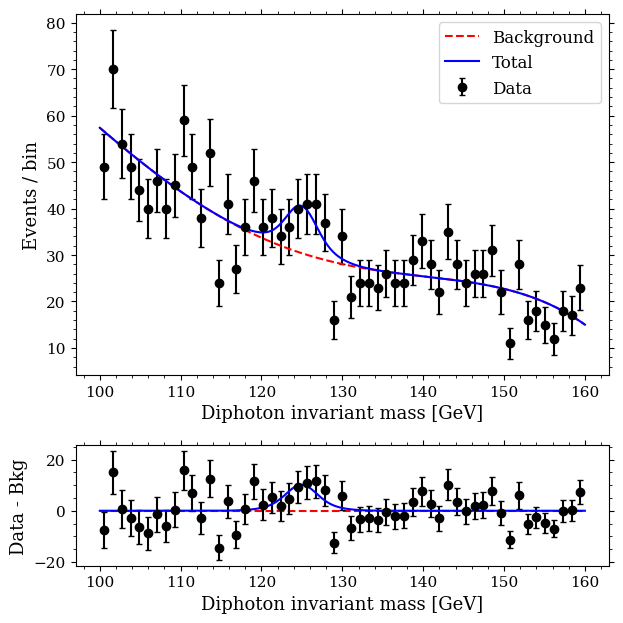

In [24]:
def totalPDF(x, b0, b1, b2, b3, b4, Nb, mu, comps=['b', 's']):
    bkg = Nb * bernstein_pdf(x, b0, b1, b2, b3, b4, hrange[0], hrange[1])
    sig = mu * smSigExp * cbg_pdf(x, **sig_pars)
    res = np.zeros_like(x)
    if 'b' in comps:
        res += bkg
    if 's' in comps:
        res += sig
    return res

# Plot fit result with residual
cx = 0.5 * (xe[1:] + xe[:-1])
bw = xe[1] - xe[0]
fig, ax = plt.subplots(2, 1, figsize=(6.4, 6.4), gridspec_kw={'height_ratios': (3, 1)})
ax[0].errorbar(cx, nh, nh**0.5, fmt='ko', label='Data')
x = np.linspace(*hrange, 400)
yb = bw * totalPDF(x, **sb_pars, comps=['b'])
ys = bw * totalPDF(x, **sb_pars, comps=['s'])
yt = bw * totalPDF(x, **sb_pars)
ax[0].plot(x, yb, 'r--', label='Background')
ax[0].plot(x, yt, 'b-', label='Total')
ax[0].legend()
ax[0].set_xlabel('Diphoton invariant mass [GeV]')
ax[0].set_ylabel('Events / bin')

# Residual
cb = bw * totalPDF(cx, **sb_pars, comps=['b'])
dy = nh - cb
ax[1].plot(hrange, [0, 0], 'r--')
ax[1].errorbar(cx, dy, nh**0.5, fmt='ko')
ax[1].plot(x, yt - yb, 'b-')
ax[1].set_xlabel('Diphoton invariant mass [GeV]')
ax[1].set_ylabel('Data - Bkg')
plt.tight_layout()
plt.savefig('figures/fit.pdf')
plt.show()

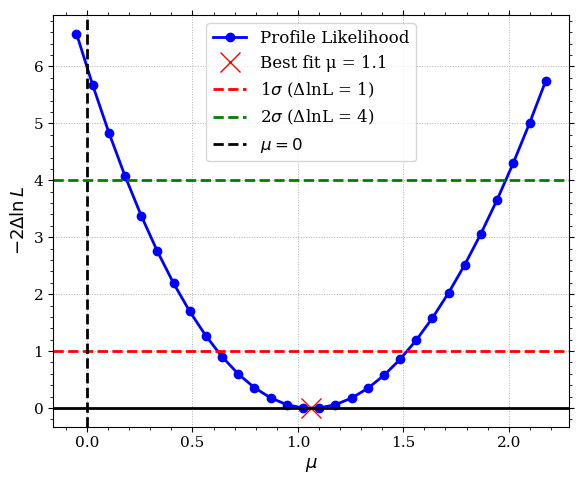

In [23]:
x, y, valid = mi.mnprofile("mu", subtract_min=True, bound=2.5)

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the likelihood profile
ax.plot(x[valid], y[valid], label='Profile Likelihood', color='blue', marker='o', linewidth=2)

# Get the best fit value (minimum)
best_mu = mi.values["mu"]
min_idx = np.argmin(y[valid])
min_x = x[valid][min_idx]
min_y = y[valid][min_idx]

# Mark the minimum point with a star
ax.plot(best_mu, 0, 'rx', markersize=15, label=f'Best fit μ = {best_mu:.1f}')

# Reference lines
ax.axhline(0, color='black', linewidth=2)
ax.axhline(1, color='red', linestyle='--', linewidth=2, label=r'1$\sigma$ (ΔlnL = 1)')
ax.axhline(4, color='green', linestyle='--', linewidth=2, label=r'2$\sigma$ (ΔlnL = 4)')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label=r'$\mu = 0$')

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$-2\Delta\ln L$')

ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('figures/mu_scan.pdf')
plt.show()

In [21]:
# get log-likelihood ratio
d2ll = bkgo_n2ll - sb_n2ll
signif = d2ll**0.5

print(f'-2\Delta ln L = {d2ll:4.2f}')
print(f'Wilks\' significance = {signif:4.2f}')

-2\Delta ln L = 5.99
Wilks' significance = 2.45
